In [1]:
import pandas as pd

Basic Operations
1️⃣ Display first 5 rows
2️⃣ Display last 3 rows
3️⃣ Find:
Shape of dataset
Column names
Data types
Number of unique departments
4️⃣ Check:
Any missing values?
Summary statistics (describe())


In [2]:
import pandas as pd
import numpy as np
data = {
    "Student_ID": [101,102,103,104,105,106,107,108],
    "Name": ["Rahul","Anita","Kiran","Sneha","Arjun","Meena","Vikram","Pooja"],
    "Department": ["CSE","IT","CSE","ECE","IT","CSE","ECE","IT"],
    "Gender": ["M","F","M","F","M","F","M","F"],
    "Maths": [85,78,92,70,88,95,60,82],
    "Physics": [80,75,89,72,84,90,65,79],
    "Programming": [90,85,94,68,91,97,70,88],
    "Attendance(%)": [92,88,95,80,85,98,75,90]
}
df=pd.DataFrame(data).set_index("Student_ID")
print(df.head(5))
print(df.tail(3))
print(df.shape)
print(df.columns)
print(df.dtypes)
print(pd.unique(df['Department']))
print(df.isnull().sum())

             Name Department Gender  Maths  Physics  Programming  \
Student_ID                                                         
101         Rahul        CSE      M     85       80           90   
102         Anita         IT      F     78       75           85   
103         Kiran        CSE      M     92       89           94   
104         Sneha        ECE      F     70       72           68   
105         Arjun         IT      M     88       84           91   

            Attendance(%)  
Student_ID                 
101                    92  
102                    88  
103                    95  
104                    80  
105                    85  
              Name Department Gender  Maths  Physics  Programming  \
Student_ID                                                          
106          Meena        CSE      F     95       90           97   
107         Vikram        ECE      M     60       65           70   
108          Pooja         IT      F     82       7

🟡 Level 2: Filtering & Selection
5️⃣ Students with:
Programming > 90
Attendance < 85
Department == "CSE"
6️⃣ Female students with Maths > 80
7️⃣ Select only columns:
Name, Department, Programming

In [2]:
print(df[df['Programming']>90])
print(df[df['Attendance(%)']<85])
print(df[df['Department']=='CSE'])
print(df[['Name','Department','Programming']])
df[(df["Gender"].str.upper() == "F") & (df["Maths"] > 80)]

             Name Department Gender  Maths  Physics  Programming  \
Student_ID                                                         
103         Kiran        CSE      M     92       89           94   
105         Arjun         IT      M     88       84           91   
106         Meena        CSE      F     95       90           97   

            Attendance(%)  
Student_ID                 
103                    95  
105                    85  
106                    98  
              Name Department Gender  Maths  Physics  Programming  \
Student_ID                                                          
104          Sneha        ECE      F     70       72           68   
107         Vikram        ECE      M     60       65           70   

            Attendance(%)  
Student_ID                 
104                    80  
107                    75  
             Name Department Gender  Maths  Physics  Programming  \
Student_ID                                                    

,Name,Department,Gender,Maths,Physics,Programming,Attendance(%)
Student_ID,,,,,,,
106,Meena,CSE,F,95,90,97,98
108,Pooja,IT,F,82,79,88,90


🔵 Level 3: New Columns & Transformations
8️⃣ Create new column:
Total_Marks (Maths + Physics + Programming)
9️⃣ Create:
Average_Marks
🔟 Create Grade column:
Avg ≥ 90 → A
80–89 → B
70–79 → C
Below 70 → D
1️⃣1️⃣ Increase all marks by 5

In [8]:
import pandas as pd
import numpy as np
data = {
    "Student_ID": [101,102,103,104,105,106,107,108],
    "Name": ["Rahul","Anita","Kiran","Sneha","Arjun","Meena","Vikram","Pooja"],
    "Department": ["CSE","IT","CSE","ECE","IT","CSE","ECE","IT"],
    "Gender": ["M","F","M","F","M","F","M","F"],
    "Maths": [85,78,92,70,88,95,60,82],
    "Physics": [80,75,89,72,84,90,65,79],
    "Programming": [90,85,94,68,91,97,70,88],
    "Attendance(%)": [92,88,95,80,85,98,75,90]
}
df = pd.DataFrame(data).set_index("Student_ID")
df['Total_Marks'] = df['Maths'] + df['Physics'] + df['Programming']
df["Average_Marks"] = df[["Maths", "Physics", "Programming"]].mean(axis=1)
df['Grade'] = 'D'
df.loc[df["Average_Marks"] >= 90, "Grade"] = "A"
df.loc[(df["Average_Marks"] >= 80) & (df["Average_Marks"] < 90), "Grade"] = "B"
df.loc[(df["Average_Marks"] >= 70) & (df["Average_Marks"] < 80), "Grade"] = "C"
print(df)
df[['Maths','Physics','Programming']]=df[['Maths','Physics','Programming']]+5
print(df)

              Name Department Gender  Maths  Physics  Programming  \
Student_ID                                                          
101          Rahul        CSE      M     85       80           90   
102          Anita         IT      F     78       75           85   
103          Kiran        CSE      M     92       89           94   
104          Sneha        ECE      F     70       72           68   
105          Arjun         IT      M     88       84           91   
106          Meena        CSE      F     95       90           97   
107         Vikram        ECE      M     60       65           70   
108          Pooja         IT      F     82       79           88   

            Attendance(%)  Total_Marks  Average_Marks Grade  
Student_ID                                                   
101                    92          255      85.000000     B  
102                    88          238      79.333333     C  
103                    95          275      91.666667     A  

🟣 Level 4: GroupBy Practice (Very Important)
1️⃣2️⃣ Average marks department-wise
1️⃣3️⃣ Total students per department
1️⃣4️⃣ Highest Programming score per department
1️⃣5️⃣ Department with highest average attendance

In [20]:
print(df.groupby('Department')['Total_Marks'].mean())
print(df.groupby('Department').size())
print(df.groupby('Department')['Programming'].max())
avg_attendance = df.groupby('Department')['Attendance(%)'].mean()
print(avg_attendance)
print(avg_attendance.idxmax)

Department
CSE    270.666667
ECE    202.500000
IT     250.000000
Name: Total_Marks, dtype: float64
Department
CSE    3
ECE    2
IT     3
dtype: int64
Department
CSE    102
ECE     75
IT      96
Name: Programming, dtype: int64
Department
CSE    95.000000
ECE    77.500000
IT     87.666667
Name: Attendance(%), dtype: float64
<bound method Series.idxmax of Department
CSE    95.000000
ECE    77.500000
IT     87.666667
Name: Attendance(%), dtype: float64>


🔴 Level 5: Sorting & Ranking
1️⃣6️⃣ Top 3 students overall
1️⃣7️⃣ Sort by Programming descending
1️⃣8️⃣ Rank students based on Total_Marks

In [22]:
print(df.sort_values('Total_Marks', ascending=False).head(3))
print(df.sort_values('Programming', ascending=False))
print(df.sort_values('Total_Marks',ascending=False))

             Name Department Gender  Maths  Physics  Programming  \
Student_ID                                                         
106         Meena        CSE      F    100       95          102   
103         Kiran        CSE      M     97       94           99   
105         Arjun         IT      M     93       89           96   

            Attendance(%)  Total_Marks  Average_Marks Grade  
Student_ID                                                   
106                    98          282      94.000000     A  
103                    95          275      91.666667     A  
105                    85          263      87.666667     B  
              Name Department Gender  Maths  Physics  Programming  \
Student_ID                                                          
106          Meena        CSE      F    100       95          102   
103          Kiran        CSE      M     97       94           99   
105          Arjun         IT      M     93       89           96   
101 

🧠 Level 6: Analytical Thinking
1️⃣9️⃣ Find correlation between 
2️⃣0️⃣ Who is the consistent performer?
(Hint: lowest standard deviation among subjects)
2️⃣1️⃣ Create pivot table:
Rows → Department
Values → Average_Marks

In [27]:
print(df[['Maths','Physics','Programming']].corr())
df['Std_Dev'] = df[['Maths','Physics','Programming']].std(axis=1)
print("Consistent performors are:",df[['Name','Std_Dev']].sort_values('Std_Dev'))
pd.pivot_table(
    df,
    index='Department',
    values='Average_Marks',
    aggfunc='mean'
)

                Maths   Physics  Programming
Maths        1.000000  0.985438     0.949386
Physics      0.985438  1.000000     0.914011
Programming  0.949386  0.914011     1.000000
Consistent performors are:               Name   Std_Dev
Student_ID                  
104          Sneha  2.000000
103          Kiran  2.516611
105          Arjun  3.511885
106          Meena  3.605551
108          Pooja  4.582576
101          Rahul  5.000000
107         Vikram  5.000000
102          Anita  5.131601


,Average_Marks
Department,
CSE,90.222222
ECE,67.500000
IT,83.333333


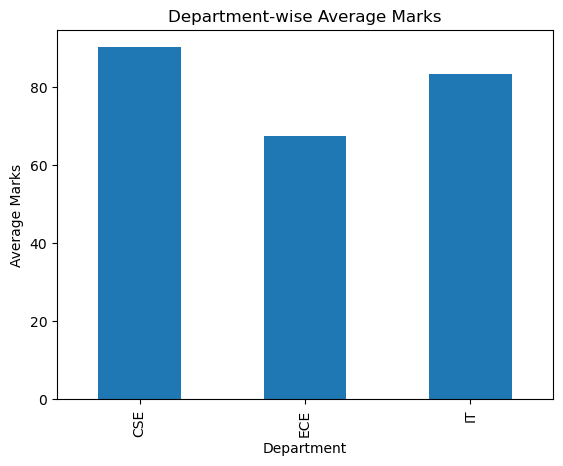

In [28]:
import matplotlib.pyplot as plt

dept_avg = df.groupby('Department')['Average_Marks'].mean()

dept_avg.plot(kind='bar')
plt.title("Department-wise Average Marks")
plt.ylabel("Average Marks")
plt.xlabel("Department")
plt.show()

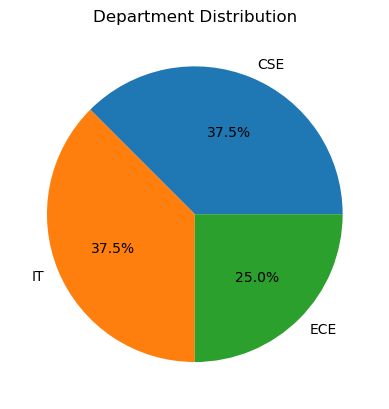

In [29]:
dept_count = df['Department'].value_counts()

dept_count.plot(kind='pie', autopct='%1.1f%%')
plt.title("Department Distribution")
plt.ylabel("")
plt.show()

In [30]:
at_risk = df[
    (df['Average_Marks'] < 75) &
    (df['Attendance(%)'] < 85)
]

at_risk[['Name','Average_Marks','Attendance(%)']]

,Name,Average_Marks,Attendance(%)
Student_ID,,,
104,Sneha,70.0,80
107,Vikram,65.0,75
